Merging datasets with label

In [13]:
import pandas as pd
import numpy as np
import os

# read csv files
kor = pd.read_csv('/content/kor_shortend.csv')
neuro = pd.read_csv('/content/neuro_shortend.csv')

In [14]:
# print heads
print(kor.head())
print(kor.shape)
print()
print(neuro.head())

    HGB    PT    MCV    GLU       %IG    CRP      MONO  patient_age        EO  \
0  12.6   NaN   74.3    NaN  0.300000  4.720  0.430000        56.07  0.100000   
1   8.0   NaN  115.3  115.0  0.300000  1.230  0.885000        78.42  0.250000   
2  14.7  12.0   88.5  306.0  0.600000  2.500  0.880000        82.59  0.350000   
3   NaN   NaN    NaN    NaN       NaN    NaN       NaN        79.53       NaN   
4  15.0  11.0   88.1  116.5  0.466667  1.165  0.613333        79.54  0.096667   

        %EO  ...        MCH        RDW         K      NEUT  LYMPH   INR  \
0  1.400000  ...  23.400000  16.600000  4.500000  4.850000  1.580   NaN   
1  5.250000  ...  36.600000  19.800000  5.200000  2.480000  1.165   NaN   
2  2.800000  ...  28.300000  12.200000  3.600000  6.050000  5.040  1.07   
3       NaN  ...        NaN        NaN  5.700000       NaN    NaN   NaN   
4  1.433333  ...  30.233333  12.866667  4.633333  5.983333  1.720  0.89   

      %LYMPH  WAPTT     custom_id      %MONO  
0  22.700000   

In [15]:
# przypisanie label do data sets
neuro['label'] = 1
kor['label'] = 0

In [16]:
# połączenie datasetów
aneurysm_concatted = pd.concat([kor, neuro], axis=0)

aneurysm_concatted.shape

(78197, 42)

In [17]:
# save concatted to csv
aneurysm_concatted.to_csv('aneurysm_concatted.csv', index=False)

In [6]:
counts = aneurysm_concatted['label'].value_counts()
percentages = aneurysm_concatted['label'].value_counts(normalize=True) * 100
for idx in counts.index:
    name = "Pozytywni (Tętniak [1])" if idx == 1 else "Nieoznaczeni (Unlabeled [0])"
    print(f"{name}: {counts[idx]} pomiarów ({percentages[idx]:.2f}%)")

Nieoznaczeni (Unlabeled [0]): 29694 pomiarów (81.70%)
Pozytywni (Tętniak [1]): 6651 pomiarów (18.30%)


In [8]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 9.3 MB/s eta 0:00:00


In [18]:
import phik
# analiza korelacji ze zmienna 'label'

df_numeric = aneurysm_concatted.select_dtypes(include=['float64', 'int64'])
df_numeric = df_numeric.drop('patient_id', axis=1)

# Pearson
corr_pearson = df_numeric.corr(method='pearson')['label'].drop('label').sort_values(ascending=False)
# Spearman
corr_spearman = df_numeric.corr(method='spearman')['label'].drop('label').sort_values(ascending=False)
# Kendall
corr_kendall = df_numeric.corr(method='kendall')['label'].drop('label').sort_values(ascending=False)
# Phi-K
corr_phik = df_numeric.phik_matrix()['label'].drop('label').sort_values(ascending=False)

interval columns not set, guessing: ['HGB', 'PT', 'MCV', 'GLU', '%IG', 'CRP', 'MONO', 'patient_age', 'EO', '%EO', 'APTT', '%BAZO', 'MPV', 'RBC', 'WBC', 'BAZO', 'IG', 'patient_sex', 'KREA', 'eGFRCKD', 'PLT', 'HCT', '%NRBC', 'NRBC', 'MCHC', 'Na', 'WPT', '%NEUT', 'eGFR-MDRD', 'MCH', 'RDW', 'K', 'NEUT', 'LYMPH', 'INR', '%LYMPH', 'WAPTT', '%MONO', 'label']


/tmp/ipykernel_8602/2804415936.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors, ax=ax)
/tmp/ipykernel_8602/2804415936.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors, ax=ax)
/tmp/ipykernel_8602/2804415936.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors, ax=ax)
/tmp/ipykernel_8602/2804415936.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

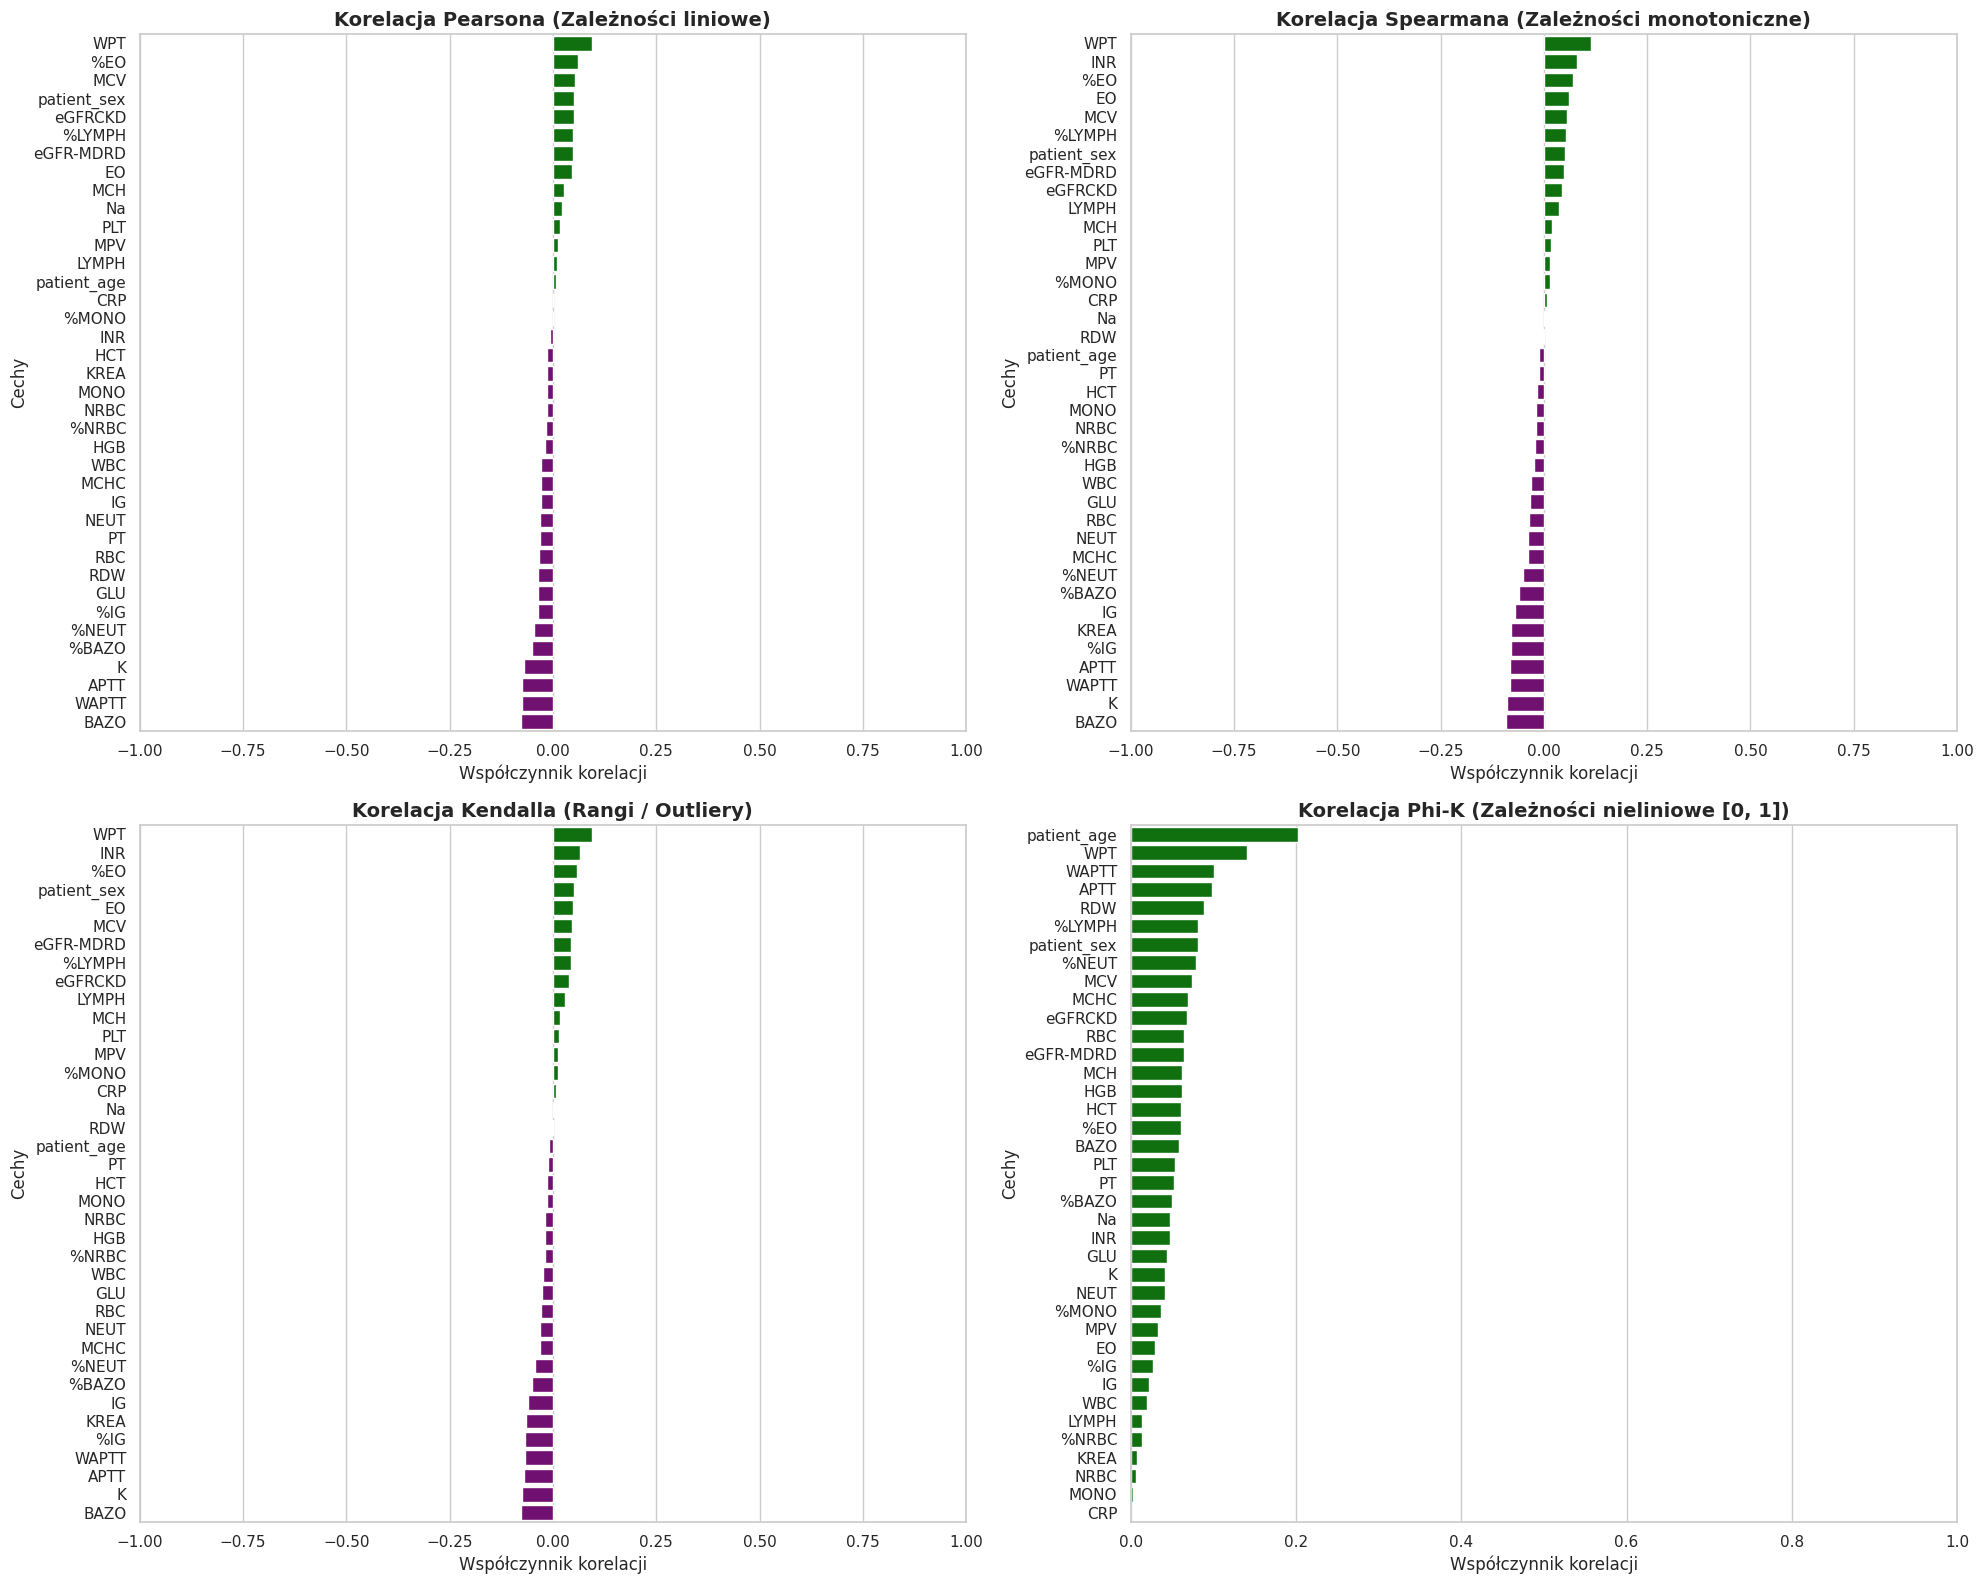

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import correlation_report

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.set_theme(style="whitegrid")

def plot_correlation(ax, data, title, is_phik=False):
    colors = ['green' if c > 0 else 'purple' for c in data.values]

    sns.barplot(x=data.values, y=data.index, palette=colors, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Współczynnik korelacji', fontsize=12)
    ax.set_ylabel('Cechy', fontsize=12)

    # Standaryzacja osi X dla czytelności
    if is_phik:
        ax.set_xlim(0, 1)  # Phi-K przyjmuje tylko wartości 0-1
    else:
        ax.set_xlim(-1, 1) # Pozostałe przyjmują -1 do 1

# Rysowanie na poszczególnych podwykresach
plot_correlation(axes[0, 0], corr_pearson, 'Korelacja Pearsona (Zależności liniowe)')
plot_correlation(axes[0, 1], corr_spearman, 'Korelacja Spearmana (Zależności monotoniczne)')
plot_correlation(axes[1, 0], corr_kendall, 'Korelacja Kendalla (Rangi / Outliery)')
plot_correlation(axes[1, 1], corr_phik, 'Korelacja Phi-K (Zależności nieliniowe [0, 1])', is_phik=True)

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

In [20]:
from collections import Counter

def get_least_correlated_directional(corr_series, n=10):
    # Dla miar [-1, 1] patrzymy na wartość bezwzględną
    return corr_series.abs().sort_values(ascending=True).head(n)

def get_least_correlated_phik(corr_series, n=10):
    # Dla Phi-K [0, 1] po prostu sortujemy rosnąco od 0
    return corr_series.sort_values(ascending=True).head(n)

# TOP 10 dla każdego testu
least_pearson = get_least_correlated_directional(corr_pearson)
least_spearman = get_least_correlated_directional(corr_spearman)
least_kendall = get_least_correlated_directional(corr_kendall)
least_phik = get_least_correlated_phik(corr_phik)

print("TOP 10 NAJMNIEJ SKORELOWANYCH PARAMETRÓW")
print(f"--- PEARSON ---\n{least_pearson}\n")
print(f"--- SPEARMAN ---\n{least_spearman}\n")
print(f"--- KENDALL ---\n{least_kendall}\n")
print(f"--- PHI-K ---\n{least_phik}\n")

all_least_correlated = (
    least_pearson.index.tolist() +
    least_spearman.index.tolist() +
    least_kendall.index.tolist() +
    least_phik.index.tolist()
)

# Zliczamy, ile razy dana cecha pojawiła się na liscie
feature_counts = Counter(all_least_correlated)

df_noise = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['Liczba_wystapien_jako_szum'])
df_noise.index.name = 'Parametr'

# Sortujemy po ilości wystąpień
df_noise = df_noise.sort_values(by=['Liczba_wystapien_jako_szum', 'Parametr'], ascending=[False, True])

print("TOP 20 GLOBALNIE NAJMNIEJ SKORELOWANYCH (CZĘŚĆ WSPÓLNA)")
print(df_noise.head(20))

TOP 10 NAJMNIEJ SKORELOWANYCH PARAMETRÓW
--- PEARSON ---
%MONO          0.000221
CRP            0.000948
INR            0.006632
patient_age    0.007383
LYMPH          0.010766
MPV            0.012580
HCT            0.013728
KREA           0.014903
MONO           0.014947
NRBC           0.015138
Name: label, dtype: float64

--- SPEARMAN ---
RDW            0.003047
Na             0.003659
CRP            0.008455
patient_age    0.011209
PT             0.013004
%MONO          0.014570
MPV            0.014700
HCT            0.017522
PLT            0.018310
MONO           0.018338
Name: label, dtype: float64

--- KENDALL ---
RDW            0.002503
Na             0.003067
CRP            0.006915
patient_age    0.009153
PT             0.011505
%MONO          0.011932
MPV            0.012102
HCT            0.014326
PLT            0.014965
MONO           0.015016
Name: label, dtype: float64

--- PHI-K ---
CRP      0.000000
MONO     0.002728
NRBC     0.006671
KREA     0.007550
%NRBC    0.013725

In [21]:
# save to csv without CRP, MONO, %MONO
features_to_drop = df_noise.head(3).index.tolist()
print("Parametry do usunięcia:", features_to_drop)

Parametry do usunięcia: ['CRP', 'MONO', '%MONO']


In [22]:
aneurysm_concatted_cleaned = aneurysm_concatted.drop(columns=features_to_drop)
print(aneurysm_concatted_cleaned.head())

    HGB    PT    MCV    GLU       %IG  patient_age        EO       %EO  APTT  \
0  12.6   NaN   74.3    NaN  0.300000        56.07  0.100000  1.400000   NaN   
1   8.0   NaN  115.3  115.0  0.300000        78.42  0.250000  5.250000   NaN   
2  14.7  12.0   88.5  306.0  0.600000        82.59  0.350000  2.800000  25.0   
3   NaN   NaN    NaN    NaN       NaN        79.53       NaN       NaN   NaN   
4  15.0  11.0   88.1  116.5  0.466667        79.54  0.096667  1.433333  33.0   

      %BAZO  ...        MCH        RDW         K      NEUT  LYMPH   INR  \
0  0.100000  ...  23.400000  16.600000  4.500000  4.850000  1.580   NaN   
1  0.800000  ...  36.600000  19.800000  5.200000  2.480000  1.165   NaN   
2  0.500000  ...  28.300000  12.200000  3.600000  6.050000  5.040  1.07   
3       NaN  ...        NaN        NaN  5.700000       NaN    NaN   NaN   
4  0.266667  ...  30.233333  12.866667  4.633333  5.983333  1.720  0.89   

      %LYMPH  WAPTT     custom_id label  
0  22.700000    NaN   91-2

In [23]:
# save to csv
aneurysm_concatted_cleaned.to_csv('aneurysm_concatted_cleaned.csv', index=False)